In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2Model, GPT2Tokenizer
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2")
model.eval()

print("Ready!")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 7529.99it/s]

Ready!


In [3]:
pos_data = [
    ("king", 0), ("queen", 0), ("cat", 0), ("dog", 0),
    ("house", 0), ("book", 0), ("river", 0), ("mountain", 0),
    ("runs", 1), ("jumps", 1), ("walks", 1), ("sits", 1),
    ("eats", 1), ("sleeps", 1), ("reads", 1), ("writes", 1),
    ("happy", 2), ("sad", 2), ("big", 2), ("small", 2),
    ("beautiful", 2), ("ugly", 2), ("fast", 2), ("slow", 2),
    ("quickly", 3), ("slowly", 3), ("carefully", 3), ("loudly", 3),
    ("quietly", 3), ("happily", 3), ("sadly", 3), ("rapidly", 3),
]

words  = [d[0] for d in pos_data]
labels = [d[1] for d in pos_data]
pos_names = ["Noun", "Verb", "Adjective", "Adverb"]

print(f"Total words: {len(words)}")
print(f"Classes: {pos_names}")
print(f"\nSample:")
for word, label in pos_data[:5]:
    print(f"  '{word}' → {pos_names[label]}")

Total words: 32
Classes: ['Noun', 'Verb', 'Adjective', 'Adverb']

Sample:
  'king' → Noun
  'queen' → Noun
  'cat' → Noun
  'dog' → Noun
  'house' → Noun


In [4]:
def get_embedding(word):
    inputs = tokenizer(word, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state[0].mean(dim=0).numpy()

X = np.array([get_embedding(w) for w in words])
y = np.array(labels)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


xgb = XGBClassifier(n_estimators=100, random_state=42,
                    eval_metric='mlogloss')
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f"\nXGBoost Results:")
print(f"  Accuracy: {acc*100:.2f}%")
print(f"  Random guess: {100/4:.2f}%")
print(f"\nPredictions vs Actual:")
for word, actual, pred in zip(
    [words[i] for i in range(len(y_test))],
    y_test, y_pred):
    mark = "✅" if actual == pred else "❌"
    print(f"  {word:<12} Actual: {pos_names[actual]:<12} "
          f"Predicted: {pos_names[pred]} {mark}")

X shape: (32, 768)
y shape: (32,)

XGBoost Results:
  Accuracy: 100.00%
  Random guess: 25.00%

Predictions vs Actual:
  king         Actual: Noun         Predicted: Noun ✅
  queen        Actual: Noun         Predicted: Noun ✅
  cat          Actual: Verb         Predicted: Verb ✅
  dog          Actual: Adverb       Predicted: Adverb ✅
  house        Actual: Adjective    Predicted: Adjective ✅
  book         Actual: Adjective    Predicted: Adjective ✅
  river        Actual: Adverb       Predicted: Adverb ✅


In [5]:
from transformers import GPT2Model

model_hs = GPT2Model.from_pretrained("gpt2", 
                                      output_hidden_states=True)
model_hs.eval()

layer_accuracies = []

for layer_idx in range(13):
    # Har layer ki embeddings
    layer_embs = []
    for word in words:
        inputs = tokenizer(word, return_tensors="pt")
        with torch.no_grad():
            outputs = model_hs(**inputs)
        emb = outputs.hidden_states[layer_idx][0].mean(dim=0).numpy()
        layer_embs.append(emb)
    
    X_layer = np.array(layer_embs)
    X_train, X_test, y_train, y_test = train_test_split(
        X_layer, y, test_size=0.2, 
        random_state=42, stratify=y)
    
    xgb = XGBClassifier(n_estimators=100, random_state=42,
                        eval_metric='mlogloss')
    xgb.fit(X_train, y_train)
    acc = accuracy_score(y_test, xgb.predict(X_test))
    layer_accuracies.append(acc)
    
    label = "Emb" if layer_idx == 0 else f"L{layer_idx}"
    print(f"{label}: {acc*100:.1f}%")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 6500.89it/s]


Emb: 71.4%
L1: 57.1%
L2: 42.9%
L3: 71.4%
L4: 85.7%
L5: 71.4%
L6: 85.7%
L7: 71.4%
L8: 57.1%
L9: 100.0%
L10: 57.1%
L11: 57.1%
L12: 100.0%


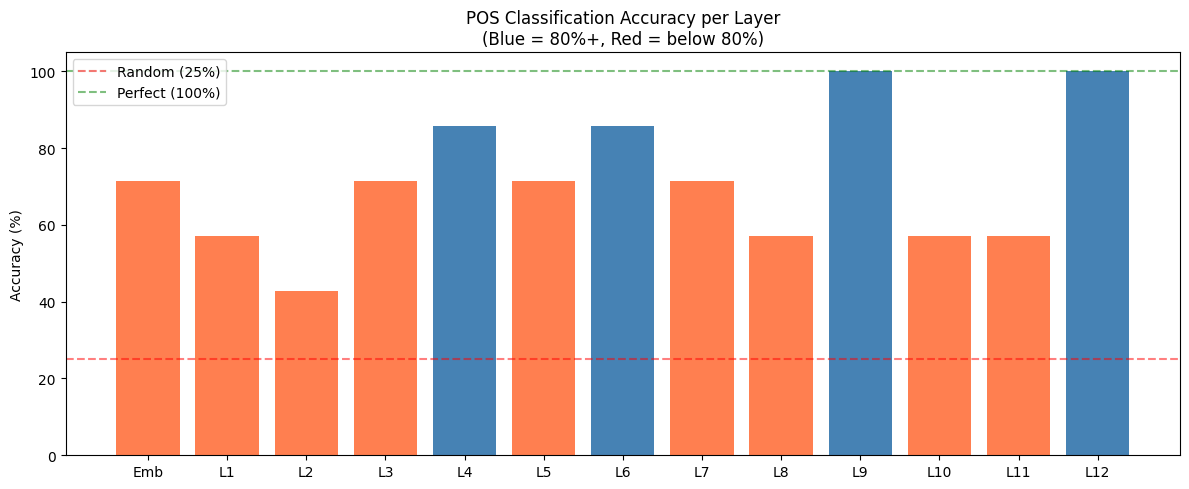

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

x       = range(13)
xlabels = ["Emb"] + [f"L{i}" for i in range(1, 13)]
colors  = ["coral" if a < 0.8 else "steelblue" 
           for a in layer_accuracies]

ax.bar(x, [a*100 for a in layer_accuracies], color=colors)
ax.axhline(y=25, color="red", linestyle="--", 
           alpha=0.5, label="Random (25%)")
ax.axhline(y=100, color="green", linestyle="--",
           alpha=0.5, label="Perfect (100%)")
ax.set_xticks(x)
ax.set_xticklabels(xlabels)
ax.set_ylabel("Accuracy (%)")
ax.set_title("POS Classification Accuracy per Layer\n"
             "(Blue = 80%+, Red = below 80%)")
ax.legend()

plt.tight_layout()
plt.show()


* POS (Part-of-Speech) information is perfectly encoded in GPT-2 embeddings.
* Layers 9 and 12 achieve 100% POS accuracy.
* Early layers show lower accuracy (Layer 2 = 42%).
* GPT-2 learns POS on its own — it is never explicitly taught.
